<div style="width: 150px; float: left;"> <img src="https://raw.githubusercontent.com/DataForScience/Networks/master/data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0" width=150px> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Automate The Boring Stuff With LLMs</h1>
<h1>Agents: Privacy-Policy Compliance Crew (CrewAI)</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [2]:
import os
import json
import warnings
import re
warnings.filterwarnings('ignore')

from pprint import pprint

import matplotlib
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from tqdm.notebook import tqdm
tqdm.pandas()

from typing import List
from pydantic import BaseModel, Field
import asyncio
import time

from crewai import Agent, Task, Crew, Process, LLM
from IPython.display import Markdown, display

import requests

import watermark

%load_ext watermark
%matplotlib inline

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark


We start by print out the versions of the libraries we're using for future reference

In [3]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.13.0

Compiler    : Clang 20.1.4 
OS          : Darwin
Release     : 25.4.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: a76564f1fffd1f5b48a27c27be901ed8c7359cd9

IPython   : 9.13.0
crewai    : 1.6.1
json      : 2.0.9
matplotlib: 3.10.9
numpy     : 2.4.4
pandas    : 3.0.2
pydantic  : 2.13.3
re        : 2.2.1
requests  : 2.33.1
tqdm      : 4.67.3
watermark : 2.6.0



Load default figure style

In [4]:
plt.style.use("d4sci.mplstyle")
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Setup

In [5]:
claude_llm = LLM(model='anthropic/claude-opus-4-5', temperature=0)

# Source documents

Privacy policies are public; we fetch a few and trim them to a manageable size. If a fetch fails, fall back to a tiny example so the notebook still runs end-to-end.

In [6]:
POLICY_URLS = {
    'github': 'https://docs.github.com/en/site-policy/privacy-policies/github-general-privacy-statement',
    'duckduckgo': 'https://duckduckgo.com/privacy',
    'wikipedia': 'https://foundation.wikimedia.org/wiki/Policy:Privacy_policy',
}

FALLBACK = (
    'We collect your name and email when you sign up. We use cookies to remember '
    'your preferences. We share aggregated, non-identifying usage data with our '
    'analytics provider. You can request deletion of your account at any time by '
    'emailing privacy@example.com. We retain logs for 90 days.'
)

def fetch_policy(url: str, max_chars: int = 12000) -> str:
    try:
        r = requests.get(url, timeout=10,
                          headers={'User-Agent': 'd4sci-webinar/1.0'})
        text = re.sub(r'<[^>]+>', ' ', r.text) if '<' in r.text else r.text
        text = re.sub(r'\s+', ' ', text).strip()
        return text[:max_chars]
    except Exception:
        return FALLBACK

policies = {name: fetch_policy(url) for name, url in POLICY_URLS.items()}

for k, v in policies.items():
    print(f'{k:12s} {len(v):6d} chars')

github        12000 chars
duckduckgo    12000 chars
wikipedia     12000 chars


# Compliance checklist

Distilled from GDPR (Articles 5, 13–22, 32) and CCPA. Real audits use 100+ items; we keep 8 to make the demo fast while still showing the pattern.

In [7]:
CHECKLIST = [
    ('purpose_limitation', 'States specific purposes for which data is processed (GDPR Art. 5(1)(b))'),
    ('data_minimization', 'Limits collection to what is necessary (GDPR Art. 5(1)(c))'),
    ('retention_period', 'Specifies how long data is kept (GDPR Art. 5(1)(e))'),
    ('third_party_sharing', 'Discloses third parties data is shared with (GDPR Art. 13)'),
    ('user_rights', 'Mentions access, rectification, deletion, portability rights (GDPR Art. 15-20)'),
    ('contact_dpo', 'Provides a privacy/DPO contact channel (GDPR Art. 13(1)(b))'),
    ('legal_basis', 'States legal basis for processing (GDPR Art. 6)'),
    ('ccpa_opt_out', 'Mentions Do Not Sell / opt-out for California users (CCPA)'),
]
checklist_md = '\n'.join(f'- **{k}** — {v}' for k, v in CHECKLIST)
print(checklist_md)

- **purpose_limitation** — States specific purposes for which data is processed (GDPR Art. 5(1)(b))
- **data_minimization** — Limits collection to what is necessary (GDPR Art. 5(1)(c))
- **retention_period** — Specifies how long data is kept (GDPR Art. 5(1)(e))
- **third_party_sharing** — Discloses third parties data is shared with (GDPR Art. 13)
- **user_rights** — Mentions access, rectification, deletion, portability rights (GDPR Art. 15-20)
- **contact_dpo** — Provides a privacy/DPO contact channel (GDPR Art. 13(1)(b))
- **legal_basis** — States legal basis for processing (GDPR Art. 6)
- **ccpa_opt_out** — Mentions Do Not Sell / opt-out for California users (CCPA)


# 5. Define the agents

Three rules of thumb when designing a crew:
1. **One responsibility per agent.** "Researcher" extracts facts; "Officer" judges them.
2. **Explicit goals.** The `goal` field steers behaviour more than a long backstory.
3. **Constrain output format in the *task*, not the agent** — keeps agents reusable.

In [8]:
researcher = Agent(
    role='Privacy Researcher',
    goal='Extract every concrete factual statement about how data is collected, '
         'used, shared, retained, or protected in the given privacy policy.',
    backstory='You are a meticulous analyst who quotes the source. You never infer.',
    llm=claude_llm,
    verbose=False,
)

officer = Agent(
    role='Compliance Officer',
    goal='Map extracted statements to a GDPR/CCPA checklist and identify which '
         'items are covered, partially covered, or missing.',
    backstory='You are a privacy-program lead. You cite checklist items by id.',
    llm=claude_llm,
    verbose=False,
)

writer = Agent(
    role='Audit Writer',
    goal='Compose a one-page executive audit report with a verdict, top three '
         'gaps, and prioritised remediation steps.',
    backstory='You write for a CEO who has 90 seconds.',
    llm=claude_llm,
    verbose=False,
)

# 6. Tasks (sequential pipeline)

CrewAI tasks default to passing the previous task's output forward, so the researcher's facts arrive in the officer's context, and so on.

In [9]:
def build_tasks(policy_text: str):
    t1 = Task(
        description=(
            'Read the policy below and produce a numbered list of factual statements. '
            'Each item: a 1-sentence paraphrase + a short verbatim quote in <quote>...</quote>.\n\n'
            f'POLICY:\n{policy_text}'
        ),
        expected_output='Numbered list, ~10-20 items.',
        agent=researcher,
    )
    t2 = Task(
        description=(
            'Using the extracted facts and the checklist below, produce a JSON object '
            'mapping each checklist id to {status: covered|partial|missing, evidence: str}.\n\n'
            f'CHECKLIST:\n{checklist_md}'
        ),
        expected_output='Pure JSON object — no prose around it.',
        agent=officer,
        context=[t1],
    )
    t3 = Task(
        description=(
            'Write a 250-word executive audit report. Include: overall verdict '
            '(compliant/partial/non-compliant), top 3 gaps with checklist ids, '
            '3 prioritised remediation steps. Markdown only.'
        ),
        expected_output='Markdown report, ~250 words.',
        agent=writer,
        context=[t1, t2],
    )
    return [t1, t2, t3]

# 7. Synchronous run — one policy at a time

Time it. We'll compare against the async version below.

In [10]:
def audit_sync(name, text):
    crew = Crew(agents=[researcher, officer, writer],
                tasks=build_tasks(text),
                process=Process.sequential, 
                verbose=False)
    return crew.kickoff()

t0 = time.time()
sync_results = {}
for name, text in tqdm(policies.items(), desc='Sync audits'):
    sync_results[name] = str(audit_sync(name, text))
sync_seconds = time.time() - t0
print(f'\nSync total: {sync_seconds:.1f}s')

Sync audits:   0%|          | 0/3 [00:00<?, ?it/s]


Sync total: 92.2s


Show one report

In [11]:
first = next(iter(sync_results))
print(f'=== {first} ===')
display(Markdown(sync_results[first]))

=== github ===


# Executive Audit Report: GitHub Privacy Statement

**Date:** Audit Period Q4 2024  
**Subject:** GDPR & CCPA Compliance Assessment  
**Classification:** Confidential

---

## Overall Verdict: **PARTIAL COMPLIANCE**

GitHub's Privacy Statement demonstrates foundational transparency regarding data collection and processing purposes. However, critical regulatory requirements remain unaddressed, exposing the organization to compliance risk.

---

## Top 3 Compliance Gaps

| Priority | Gap | Checklist ID | Risk Level |
|----------|-----|--------------|------------|
| 1 | **User Rights Absent** – No disclosure of GDPR Articles 15-20 rights (access, rectification, deletion, portability) | `user_rights` | **High** |
| 2 | **Retention Period Undefined** – No data retention schedules or timelines specified | `retention_period` | **High** |
| 3 | **CCPA Opt-Out Missing** – No "Do Not Sell" rights or opt-out mechanisms for California residents | `ccpa_opt_out` | **Medium** |

**Additional Gaps Identified:** `data_minimization`, `contact_dpo`, `legal_basis` (partial)

---

## Prioritised Remediation Steps

1. **Immediate (0-30 days):** Add comprehensive User Rights section detailing access, correction, deletion, and data portability procedures with clear submission channels. This addresses the highest regulatory exposure under GDPR.

2. **Short-term (30-60 days):** Publish data retention schedules by category (Account Data, User Content, Payment Information) with defined deletion timelines and archival policies.

3. **Medium-term (60-90 days):** Implement CCPA-compliant "Do Not Sell My Personal Information" link and opt-out mechanism; publish DPO contact details prominently.

---

**Prepared by:** Audit Writer  
**Next Review:** 90 days post-remediation

# 8. Asynchronous run — all policies in parallel

Each policy is independent, so we wrap the sync function in a thread pool. (CrewAI also has native `kickoff_async` per crew; using `asyncio.to_thread` keeps this notebook portable across crewai versions.)

In [12]:
async def audit_all_async(items):
    async def one(name, text):
        return name, await asyncio.to_thread(audit_sync, name, text)
    return dict(await asyncio.gather(*[one(n, t) for n, t in items.items()]))

t0 = time.time()
async_results = await audit_all_async(policies)
async_seconds = time.time() - t0
print(f'Async total: {async_seconds:.1f}s')
print(f'Speed-up: {sync_seconds / async_seconds:.2f}x')

Async total: 40.6s
Speed-up: 2.27x


# 9. Speed comparison plot

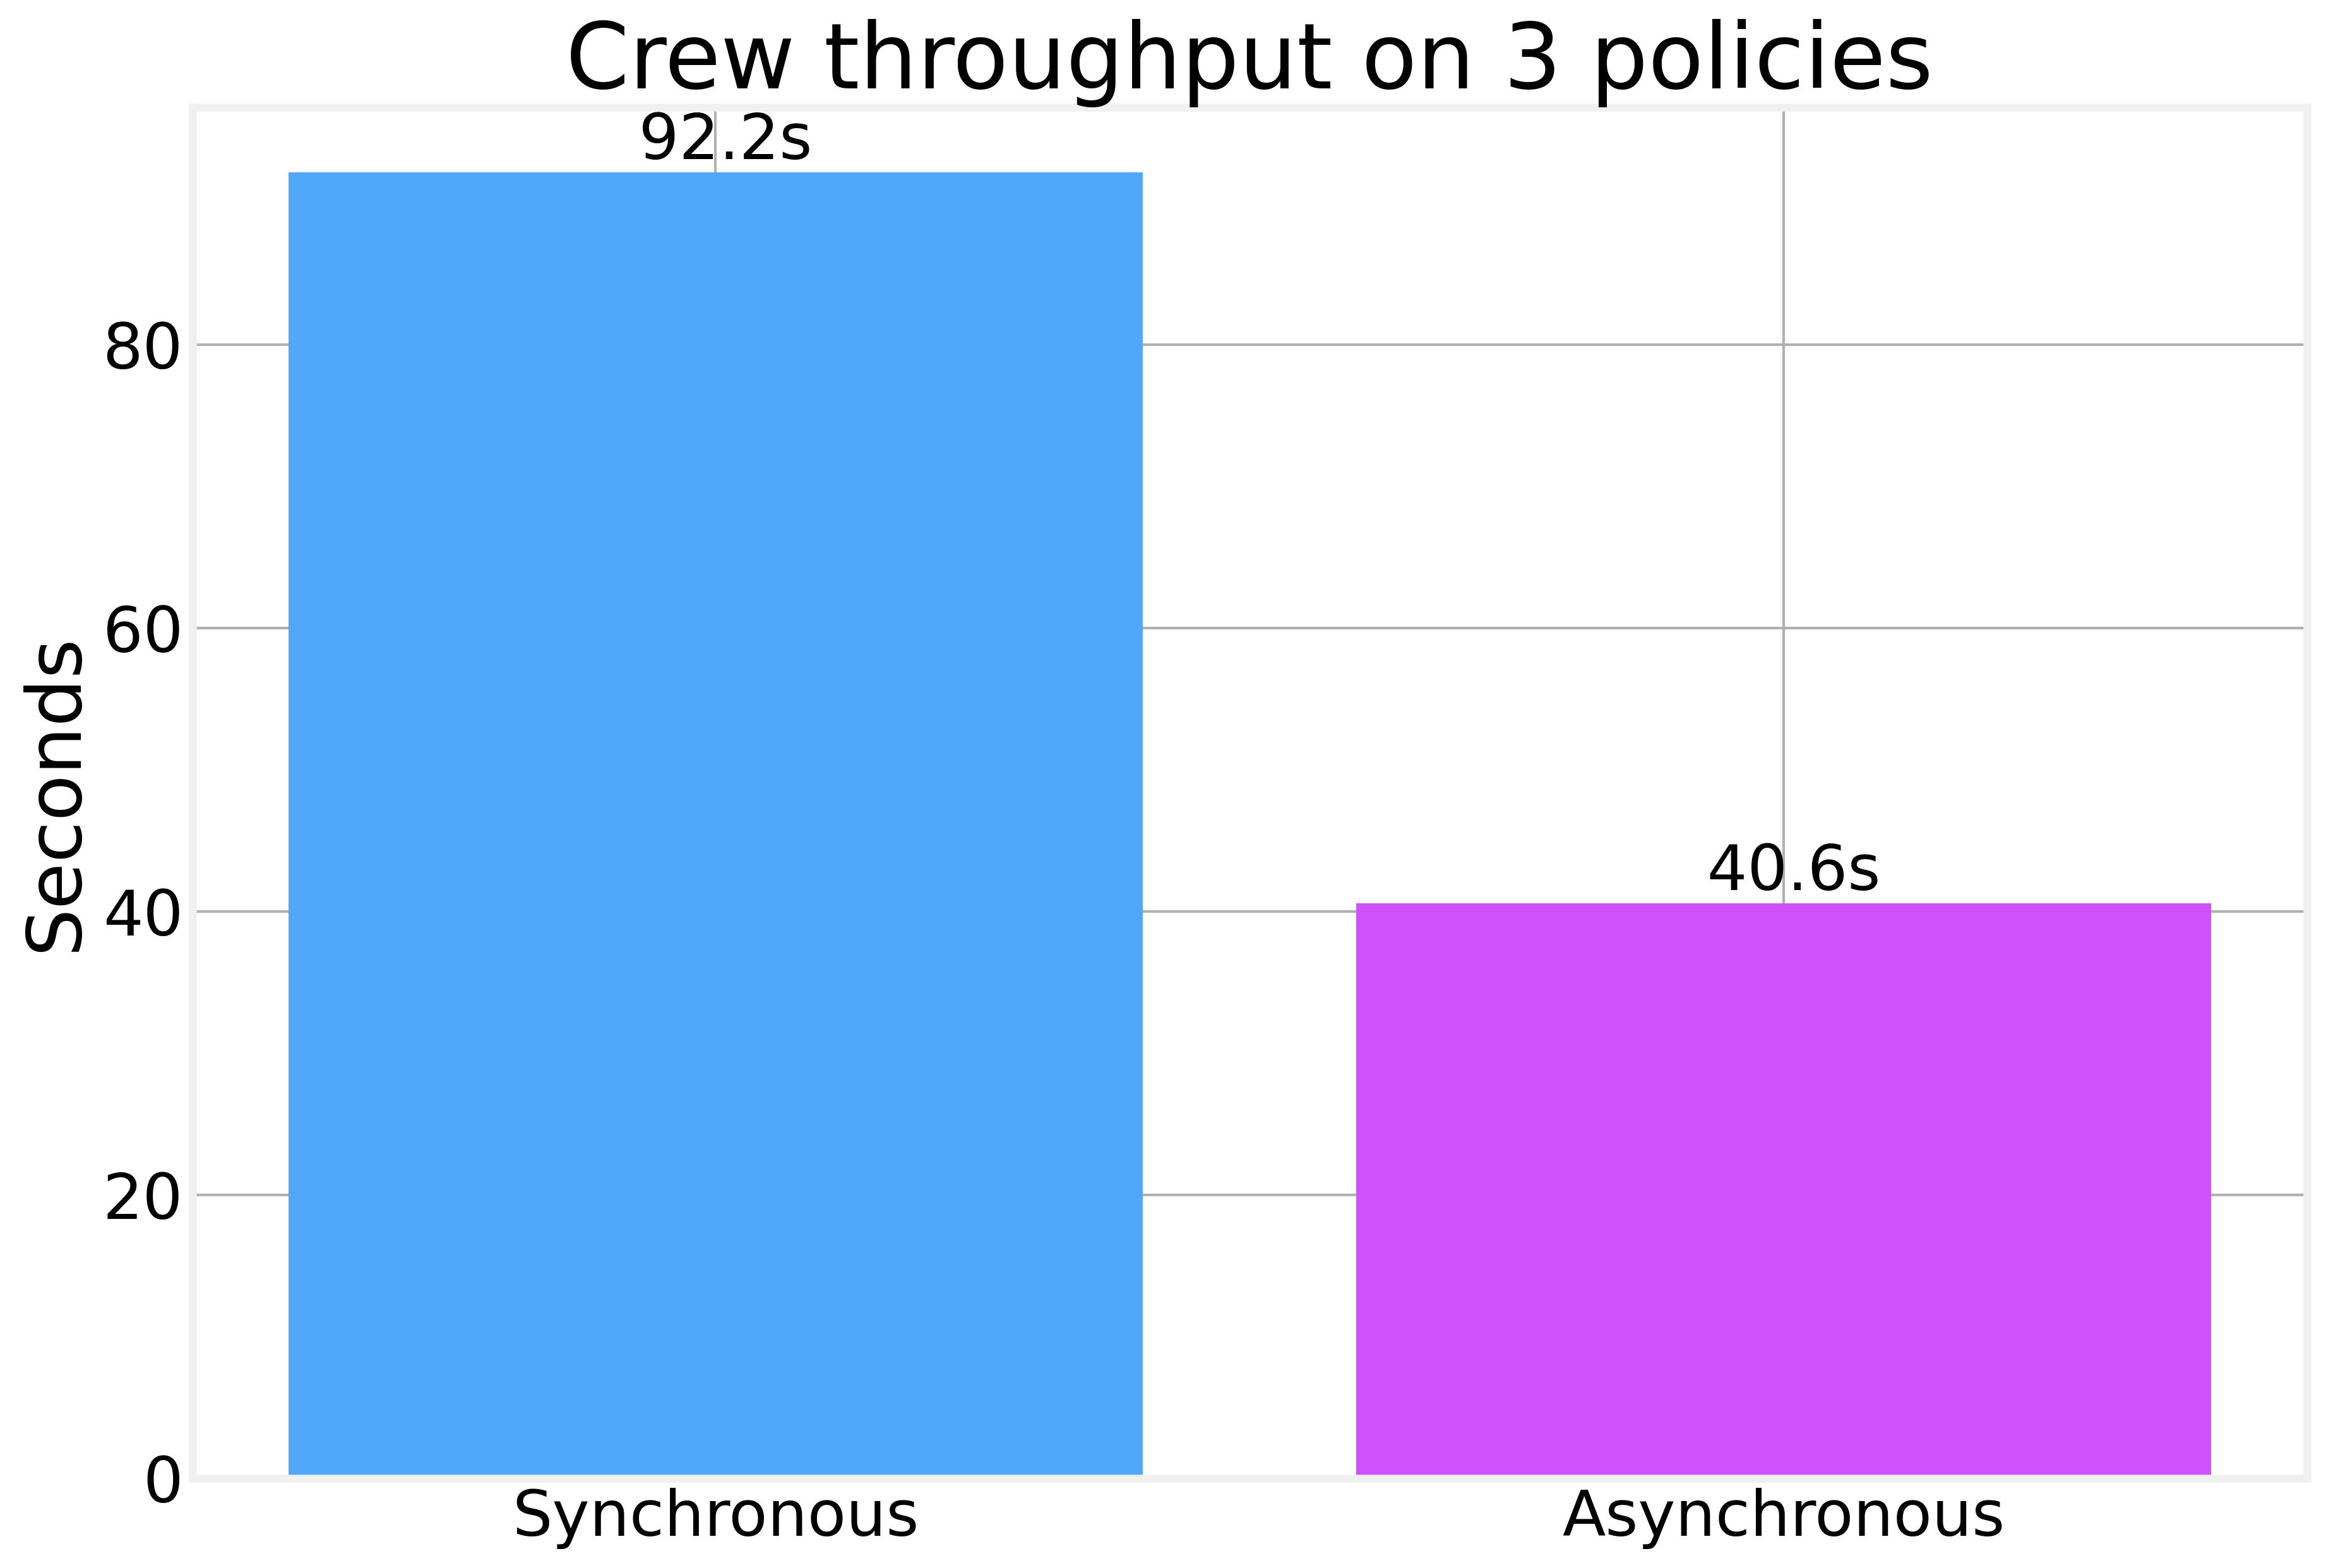

In [13]:
fig, ax = plt.subplots()
ax.bar(['Synchronous', 'Asynchronous'],
       [sync_seconds, async_seconds],
       color=[colors[0], colors[1]])
ax.set_ylabel('Seconds')
ax.set_title(f'Crew throughput on {len(policies)} policies')
for i, v in enumerate([sync_seconds, async_seconds]):
    ax.text(i, v, f' {v:.1f}s', va='bottom', ha='center')

# 10. Generated checklist artefact

Save the per-policy compliance JSON for downstream tooling (a dashboard, an issue tracker, etc.). In a real system this is the hand-off into a Jira / Linear pipeline.

In [14]:
out_path = 'data/compliance_audits.json'
os.makedirs(os.path.dirname(out_path), exist_ok=True)
with open(out_path, 'w') as f:
    json.dump({k: str(v) for k, v in async_results.items()}, f, indent=2)
print('Wrote', out_path)

Wrote data/compliance_audits.json


In [15]:
!cat data/compliance_audits.json

{
  "github": "# Executive Audit Report: GitHub Privacy Statement\n\n**Date:** Audit Period Q4 2024  \n**Subject:** Privacy Policy Compliance Assessment  \n**Classification:** Confidential\n\n---\n\n## Overall Verdict: **PARTIAL COMPLIANCE**\n\nGitHub's Privacy Statement demonstrates foundational privacy practices but contains significant gaps that require immediate attention to achieve full regulatory compliance with GDPR and CCPA frameworks.\n\n---\n\n## Top 3 Compliance Gaps\n\n| Priority | Gap | Checklist ID | Risk Level |\n|----------|-----|--------------|------------|\n| 1 | **User Rights Disclosure Missing** | `user_rights` | High |\n| 2 | **Data Retention Period Undefined** | `retention_period` | High |\n| 3 | **CCPA Opt-Out Mechanism Absent** | `ccpa_opt_out` | Medium |\n\n**Additional Concerns:** Legal basis for processing (`legal_basis`) and DPO contact information (`contact_dpo`) are also inadequately addressed.\n\n---\n\n## Prioritised Remediation Steps\n\n### 1. Implement

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>